# 1 Introduction

In [14]:
# Cut run time from 34~ minutes to 27~ minutes, need to match the cuXXX to the version of nvidia CUDA on your pc
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132


Epoch: 0
Mean Train Loss: 3.99e-01
Mean Test Loss:  2.11e-01
Epoch: 10
Mean Train Loss: 1.56e-01
Mean Test Loss:  2.76e-01
Epoch: 20
Mean Train Loss: 1.03e-01
Mean Test Loss:  3.78e-01
Epoch: 30
Mean Train Loss: 8.12e-02
Mean Test Loss:  5.31e-01
Epoch: 40
Mean Train Loss: 5.78e-02
Mean Test Loss:  8.07e-01
Epoch: 50
Mean Train Loss: 3.50e-02
Mean Test Loss:  8.45e-01
Epoch: 60
Mean Train Loss: 3.45e-02
Mean Test Loss:  7.40e-01
Epoch: 70
Mean Train Loss: 1.55e-02
Mean Test Loss:  7.57e-01
Epoch: 80
Mean Train Loss: 2.41e-02
Mean Test Loss:  1.00e+00
Epoch: 90
Mean Train Loss: 1.78e-02
Mean Test Loss:  9.16e-01
Epoch: 100
Mean Train Loss: 1.45e-02
Mean Test Loss:  9.31e-01


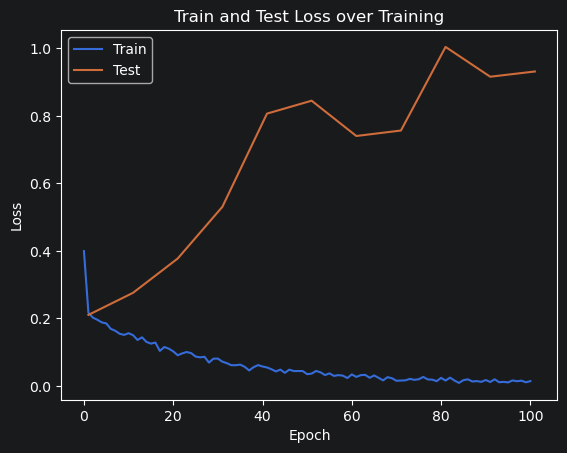

In [18]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy

plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape) * std
    w.requires_grad = True
    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)


class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])


# define the neural network
def model(x, w_h, w_h2, w_o):
    h = rectify(x @ w_h)
    h2 = rectify(h @ w_h2)
    pre_softmax = h2 @ w_o
    return pre_softmax


# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

optimizer = RMSprop(params=[w_h, w_h2, w_o])


n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = model(x, w_h, w_h2, w_o)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()

# 2 Dropout

In [7]:
# Sets random elements of X to zero (do not use pytorch's existing drop out functionality)
def dropout(X, p_drop=0.5):
    if 0 < p_drop < 1:
        for i in range(len(X)):
            if np.random.binomial(1, p_drop, 1):
                X[i] = 0
            else:
                X[i] = X[i] / (1 - p_drop)

    return X

# Define the neural network but now with 3 drop out steps
def dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h)

    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2)

    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o

    return pre_softmax

Epoch: 0
Mean Train Loss: 2.07e+00
Mean Test Loss:  4.80e-01
Epoch: 10
Mean Train Loss: 1.90e+00
Mean Test Loss:  2.13e-01
Epoch: 20
Mean Train Loss: 1.89e+00
Mean Test Loss:  1.46e-01
Epoch: 30
Mean Train Loss: 1.88e+00
Mean Test Loss:  1.24e-01
Epoch: 40
Mean Train Loss: 1.89e+00
Mean Test Loss:  1.50e-01
Epoch: 50
Mean Train Loss: 1.88e+00
Mean Test Loss:  1.54e-01
Epoch: 60
Mean Train Loss: 1.86e+00
Mean Test Loss:  1.55e-01
Epoch: 70
Mean Train Loss: 1.85e+00
Mean Test Loss:  2.33e-01
Epoch: 80
Mean Train Loss: 1.84e+00
Mean Test Loss:  1.63e-01
Epoch: 90
Mean Train Loss: 1.84e+00
Mean Test Loss:  2.00e-01
Epoch: 100
Mean Train Loss: 1.83e+00
Mean Test Loss:  2.33e-01


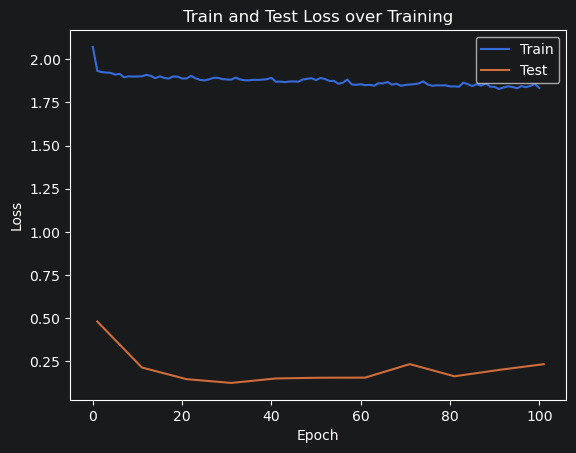

In [34]:
plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape) * std
    w.requires_grad = True
    return w


def rectify(x):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x)


class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])

# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)

optimizer = RMSprop(params=[w_h, w_h2, w_o])


n_epochs = 100

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    for idx, batch in enumerate(train_dataloader):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784)
        # feed input through model
        noise_py_x = dropout_model(x, w_h, w_h2, w_o, 0.1, 0.5)

        # reset the gradient
        optimizer.zero_grad()

        # the cross-entropy loss function already contains the softmax
        loss = cross_entropy(noise_py_x, y, reduction="mean")

        train_loss_this_epoch.append(float(loss))

        # compute the gradient
        loss.backward()
        # update weights
        optimizer.step()

    train_loss.append(np.mean(train_loss_this_epoch))

    # test periodically
    if epoch % 10 == 0:
        print(f"Epoch: {epoch}")
        print(f"Mean Train Loss: {train_loss[-1]:.2e}")
        test_loss_this_epoch = []

        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in enumerate(test_dataloader):
                x, y = batch
                x = x.reshape(batch_size, 784)
                noise_py_x = model(x, w_h, w_h2, w_o)

                loss = cross_entropy(noise_py_x, y, reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 10), test_loss, label="Test")
plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()

Task: Explain in a few sentences how the dropout method works and how it reduces overfitting. Train the model using dropout and report train and test errors. Why do we need a different model configuration for evaluating the test loss? Compare the test error with the test error from Section 1.

The dropout method works by setting random elements to zeros in each layer in the neural network. This reduces overfitting because it adds noise to the training data so the model can't perfectly align to the exact data. It forces the neural network to learn in a more unpredictable and less singular way so it is less affected by overfitting. We need a different model configuration for evaluting the test loss because the randomization in dropout means we need to evaluate it against the no dropout model to get an accurate test evaluation.

Test Error Comparison
| Method    | Mean Train Loss   | Mean Test Loss    |
| --------- | ----------------- | ----------------- |
| No Dropout| 1.45e-02          | 9.31e-01          |
| Dropout   | 1.83e+00          | 2.33e-01          |

As we can see from the results the testing error has drastically decreased in comparison to the no dropout model. This testing error implies that there is less overfitting in the model compared to the no dropout method. The dropout model has slightly worse mean training loss as a result though. The variables of p_drop_hidden could be adjusted to something lower which might improve the training loss.

# 3 Parametric ReLU


In [2]:
# Sets random elements of X to zero (do not use pytorch's existing drop out functionality)
def dropout(X, p_drop=0.5):
    if 0 < p_drop < 1:
        for i in range(len(X)):
            if np.random.binomial(1, p_drop, 1):
                X[i] = 0
            else:
                X[i] = X[i] / (1 - p_drop)

    return X

def rectify(x, a=0):
    # Rectified Linear Unit (ReLU)
    return torch.max(torch.zeros_like(x), x) + a * torch.min(torch.zeros_like(x), x)


# Define the neural network but now with 3 drop out steps
def dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h)

    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2)

    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o

    return pre_softmax

def parametric_dropout_model(X, w_h, w_h2, w_o, p_drop_input, p_drop_hidden, a1=0, a2=0):
    X = dropout(X, p_drop_input)
    h = rectify(X @ w_h, a=a1)

    h = dropout(h, p_drop_hidden)
    h2 = rectify(h @ w_h2, a=a2)
    
    h2 = dropout(h2, p_drop_hidden)
    pre_softmax = h2 @ w_o

    return pre_softmax


In [3]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torch.nn.functional import conv2d, max_pool2d, cross_entropy

from tqdm import tqdm

In [4]:
device = "cuda" #if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


  0%|          | 0/600 [00:00<?, ?it/s]/tmp/ipykernel_7066/1150204212.py:138: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_loss_this_epoch_parametric.append(float(loss))
100%|██████████| 600/600 [00:23<00:00, 25.75it/s]

Epoch: 0
Mean Train Loss (Parametric): 2.24e+00 ; a1: 3.10e-02 ; a2: -2.25e-03
Mean Train Loss: 2.05e+00



100%|██████████| 100/100 [00:00<00:00, 246.84it/s]

Mean Test Loss (Parametric):  3.64e-01
Mean Test Loss:  5.65e-01



100%|██████████| 600/600 [00:23<00:00, 25.98it/s]

...

Mean Test Loss (Parametric):  1.81e-01
Mean Test Loss:  2.16e-01



100%|██████████| 600/600 [00:22<00:00, 26.33it/s]

Epoch: 100
Mean Train Loss (Parametric): 1.88e+00 ; a1: 2.02e-02 ; a2: 1.59e-03
Mean Train Loss: 1.85e+00



100%|██████████| 100/100 [00:00<00:00, 263.74it/s]


Mean Test Loss (Parametric):  2.29e-01
Mean Test Loss:  2.41e-01


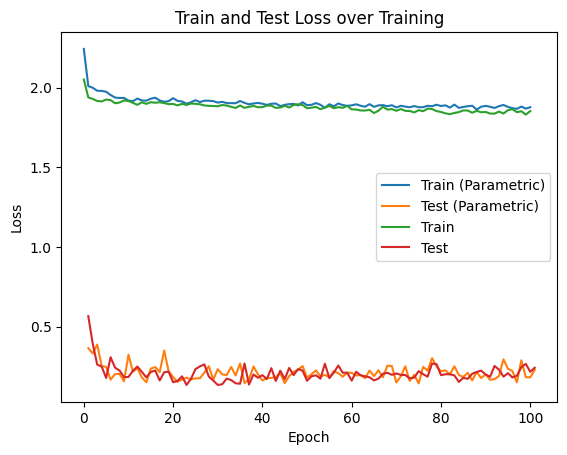

In [5]:



plt.rc("figure", dpi=100)

batch_size = 100

# transform images into normalized tensors
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = datasets.MNIST(
    "./",
    download=True,
    train=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    "./",
    download=True,
    train=False,
    transform=transform,
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

def init_weights(shape):
    # Kaiming He initialization (a good initialization is important)
    # https://arxiv.org/abs/1502.01852
    std = np.sqrt(2. / shape[0])
    w = torch.randn(size=shape).to(device) * std
    w.requires_grad = True
    return w




class RMSprop(optim.Optimizer):
    """
    This is a reduced version of the PyTorch internal RMSprop optimizer
    It serves here as an example
    """
    def __init__(self, params, lr=1e-3, alpha=0.5, eps=1e-8):
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)

    def step(self):
        for group in self.param_groups:
            for p in group['params']:
                grad = p.grad.data
                state = self.state[p]

                # state initialization
                if len(state) == 0:
                    state['square_avg'] = torch.zeros_like(p.data)

                square_avg = state['square_avg']
                alpha = group['alpha']

                # update running averages
                square_avg.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                avg = square_avg.sqrt().add_(group['eps'])

                # gradient update
                p.data.addcdiv_(grad, avg, value=-group['lr'])
                
                #print(p)
                
                #print(group)

# initialize weights

# input shape is (B, 784)
w_h = init_weights((784, 625))
# hidden layer with 625 neurons
w_h2 = init_weights((625, 625))
# hidden layer with 625 neurons
w_o = init_weights((625, 10))
# output shape is (B, 10)


optimizer = RMSprop(params=[w_h, w_h2, w_o])


# input shape is (B, 784)
w_h_parametric = w_h.clone().detach().requires_grad_(True)
# hidden layer with 625 neurons
w_h2_parametric = w_h2.clone().detach().requires_grad_(True)
# hidden layer with 625 neurons
w_o_parametric = w_o.clone().detach().requires_grad_(True)
# output shape is (B, 10)

a1_parametric = torch.nn.Parameter(torch.tensor(0.25, dtype=torch.float32, device=device), requires_grad=True)
a2_parametric = torch.nn.Parameter(torch.tensor(0.25, dtype=torch.float32, device=device), requires_grad=True)


optimizer_parametric = RMSprop(params=[w_h_parametric, w_h2_parametric, w_o_parametric, a1_parametric, a2_parametric])


n_epochs = 100

train_loss_parametric = []
test_loss_parametric = []

train_loss = []
test_loss = []

# put this into a training loop over 100 epochs
for epoch in range(n_epochs + 1):
    train_loss_this_epoch = []
    train_loss_this_epoch_parametric = []
    for idx, batch in tqdm(enumerate(train_dataloader), total=len(train_dataloader)):
        x, y = batch

        # our model requires flattened input
        x = x.reshape(batch_size, 784).to(device)
        
        # feed input through model
        noise_py_x_parametric = parametric_dropout_model(x.clone().detach(), w_h_parametric, w_h2_parametric, w_o_parametric, 0.1, 0.5, a1_parametric, a2_parametric)
        noise_py_x = dropout_model(x.clone().detach(), w_h, w_h2, w_o, 0.1, 0.5)

        optimizer_parametric.zero_grad()
        loss = cross_entropy(noise_py_x_parametric, y.clone().detach().to(device), reduction="mean")
        train_loss_this_epoch_parametric.append(float(loss))
        loss.backward(retain_graph=True)
        optimizer_parametric.step()
        
        optimizer.zero_grad()
        loss = cross_entropy(noise_py_x, y.clone().detach().to(device), reduction="mean")
        train_loss_this_epoch.append(float(loss))
        loss.backward()
        optimizer.step()
        

    train_loss_parametric.append(np.mean(train_loss_this_epoch_parametric))
    train_loss.append(np.mean(train_loss_this_epoch))

    print(f"Epoch: {epoch}")
    print(f"Mean Train Loss (Parametric): {train_loss_parametric[-1]:.2e} ; a1: {a1_parametric.item():.2e} ; a2: {a2_parametric.item():.2e}")
    print(f"Mean Train Loss: {train_loss[-1]:.2e}")

    # test periodically
    if epoch % 1 == 0:
        

        test_loss_this_epoch_parametric = []
        test_loss_this_epoch = []


        # no need to compute gradients for validation
        with torch.no_grad():
            for idx, batch in tqdm(enumerate(test_dataloader), total=len(test_dataloader)):
                x, y = batch
                x = x.reshape(batch_size, 784).to(device)
                noise_py_x_parametric = parametric_dropout_model(x, w_h_parametric, w_h2_parametric, w_o_parametric, 0.0, 0.0, a1_parametric, a2_parametric)
                noise_py_x = dropout_model(x, w_h, w_h2, w_o, 0.0, 0.0)

                loss = cross_entropy(noise_py_x_parametric, y.to(device), reduction="mean")
                test_loss_this_epoch_parametric.append(float(loss))
                
                loss = cross_entropy(noise_py_x, y.to(device), reduction="mean")
                test_loss_this_epoch.append(float(loss))

        test_loss_parametric.append(np.mean(test_loss_this_epoch_parametric))
        test_loss.append(np.mean(test_loss_this_epoch))

        print(f"Mean Test Loss (Parametric):  {test_loss_parametric[-1]:.2e}")
        print(f"Mean Test Loss:  {test_loss[-1]:.2e}")

plt.plot(np.arange(n_epochs + 1), train_loss_parametric, label="Train (Parametric)")
plt.plot(np.arange(1, n_epochs + 2, 1), test_loss_parametric, label="Test (Parametric)")
plt.plot(np.arange(n_epochs + 1), train_loss, label="Train")
plt.plot(np.arange(1, n_epochs + 2, 1), test_loss, label="Test")

plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()

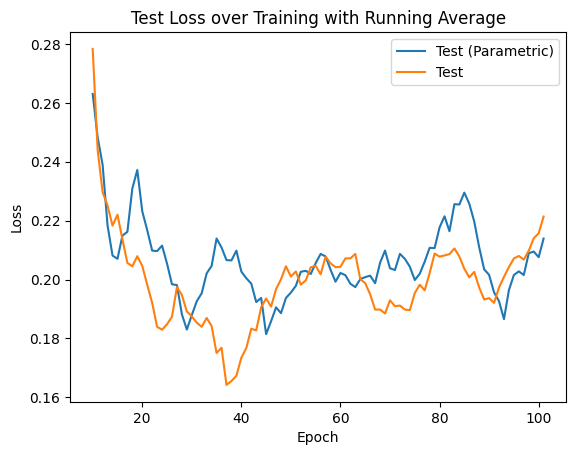

In [9]:

def running_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

plt.plot(np.arange(1 + 9, n_epochs + 2, 1), running_average(test_loss_parametric, 10), label="Test (Parametric)")
plt.plot(np.arange(1 + 9, n_epochs + 2, 1), running_average(test_loss, 10), label="Test")

plt.title("Test Loss over Training with Running Average")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()

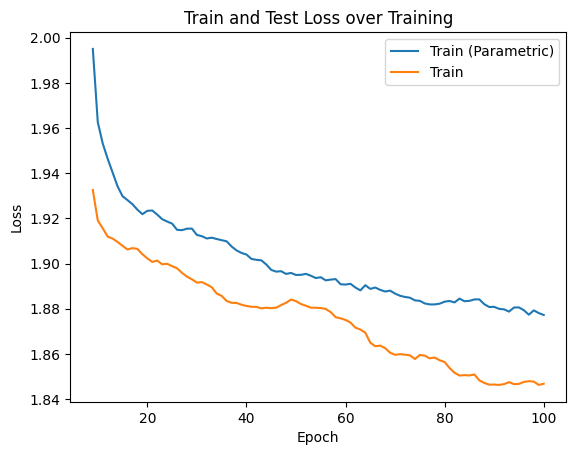

In [11]:
def running_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')


plt.plot(np.arange(9, n_epochs + 1), running_average(train_loss_parametric, 10), label="Train (Parametric)")
plt.plot(np.arange(9, n_epochs + 1), running_average(train_loss, 10), label="Train")

plt.title("Train and Test Loss over Training")
plt.xlabel("Epoch")

plt.ylabel("Loss")
plt.legend()

Task: Compare the results with the earlier excercises.


Without optimizing and just dropping it in, the trainable parametric ReLU model seems to be nearly identical or worse than the model with only dropout. It may be that if one runs more runs and tries to find statistical evidence, then it is different. But for now it seems as if it does not improve the performance.


